# Problem 2.c: Full Fine-tuning

**Objective:** Fine-tune the ENTIRE pretrained ResNet model (all layers) for the UCMerced dataset.

**Key Requirements:**
- Load pretrained ResNet50
- Replace final FC layer (1000 → 21 classes)
- **UNFREEZE ALL LAYERS** (train the entire network)
- Use a **LOWER learning rate** (0.0001 / 1e-4) for stability
- Adam optimizer
- CrossEntropyLoss
- ImageNet normalization̦
- Save model when validation loss is minimum
- Plot training/validation loss and accuracy
- Report all metrics
- Compare with Problems 2.a and 2.b

**Key Difference from 2.b:**
- In 2.b, we froze the base and trained only the head
- In 2.c, we train ALL 23+ million parameters
- Requires lower learning rate to avoid destroying pretrained features


## 1. Install Required Packages


In [4]:
%pip install torch torchvision numpy pandas scikit-learn matplotlib seaborn Pillow tqdm --quiet


## 2. Import Libraries and Setup


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import time
from tqdm import tqdm

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             precision_recall_fscore_support)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


## 3. Mount Google Drive and Set Data Path


In [6]:
# Mount Google Drive (for Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/IMGS589/HW5/UCMerced_LandUse/Images'
    print("Mounted at /content/drive")
except:
    # For local execution
    DATA_PATH = '../UCMerced_LandUse/Images'
    print("Running locally")

print(f"Data directory: {DATA_PATH}")


Mounted at /content/drive
Mounted at /content/drive
Data directory: /content/drive/MyDrive/IMGS589/HW5/UCMerced_LandUse/Images


## 4. Load Dataset Paths


In [7]:
def load_dataset_paths(root_dir):
    """Load all image paths and labels from UCMerced dataset."""
    image_paths = []
    labels = []

    class_dirs = sorted([d for d in os.listdir(root_dir)
                        if os.path.isdir(os.path.join(root_dir, d))])

    for class_name in class_dirs:
        class_path = os.path.join(root_dir, class_name)
        images = sorted([f for f in os.listdir(class_path)
                        if f.endswith(('.tif', '.jpg', '.png'))])

        for img_name in images:
            image_paths.append(os.path.join(class_path, img_name))
            labels.append(class_name)

    return np.array(image_paths), np.array(labels), class_dirs

# Load dataset
image_paths, labels, class_names = load_dataset_paths(DATA_PATH)

print(f"Classes found: {len(class_names)}")
print(f"Total images: {len(image_paths)}")
print(f"Total classes: {len(np.unique(labels))}")
print(f"\nClass names:")
for i, cls in enumerate(class_names, 1):
    count = np.sum(labels == cls)
    print(f"{i:2d}. {cls} - {count} images")


Classes found: 21
Total images: 2100
Total classes: 21

Class names:
 1. agricultural - 100 images
 2. airplane - 100 images
 3. baseballdiamond - 100 images
 4. beach - 100 images
 5. buildings - 100 images
 6. chaparral - 100 images
 7. denseresidential - 100 images
 8. forest - 100 images
 9. freeway - 100 images
10. golfcourse - 100 images
11. harbor - 100 images
12. intersection - 100 images
13. mediumresidential - 100 images
14. mobilehomepark - 100 images
15. overpass - 100 images
16. parkinglot - 100 images
17. river - 100 images
18. runway - 100 images
19. sparseresidential - 100 images
20. storagetanks - 100 images
21. tenniscourt - 100 images


## 5. Data Splitting (70/15/15 - Stratified)


In [8]:
# Encode labels to integers
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# Split: 70% train, 15% val, 15% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, test_size=0.30, random_state=SEED, stratify=labels_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Dataset splits:")
print(f"Train: {len(X_train)} images ({len(X_train)/len(image_paths)*100:.1f}%)")
print(f"Validation: {len(X_val)} images ({len(X_val)/len(image_paths)*100:.1f}%)")
print(f"Test: {len(X_test)} images ({len(X_test)/len(image_paths)*100:.1f}%)")
print(f"Total: {len(image_paths)} images")

# Verify class distribution
print(f"\nClass distribution in each split:")
print(f"Train: {np.bincount(y_train)}")
print(f"Validation: {np.bincount(y_val)}")
print(f"Test: {np.bincount(y_test)}")


Dataset splits:
Train: 1470 images (70.0%)
Validation: 315 images (15.0%)
Test: 315 images (15.0%)
Total: 2100 images

Class distribution in each split:
Train: [70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70]
Validation: [15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15]
Test: [15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15]


## 6. Define Image Transforms (ImageNet Normalization)


In [9]:
# ImageNet normalization parameters
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation and test transforms (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transform pipeline created:")
print("- Resize to 224x224")
print("- Data augmentation for training (random flips)")
print(f"- Normalize with ImageNet mean={IMAGENET_MEAN} std={IMAGENET_STD}")


Transform pipeline created:
- Resize to 224x224
- Data augmentation for training (random flips)
- Normalize with ImageNet mean=[0.485, 0.456, 0.406] std=[0.229, 0.224, 0.225]


## 7. Create Custom Dataset Class


In [10]:
class UCMercedDataset(Dataset):
    """Custom Dataset for UCMerced Land Use images."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Create datasets
train_dataset = UCMercedDataset(X_train, y_train, transform=train_transform)
val_dataset = UCMercedDataset(X_val, y_val, transform=val_test_transform)
test_dataset = UCMercedDataset(X_test, y_test, transform=val_test_transform)

print("Datasets created:")
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")


Datasets created:
Train dataset: 1470 samples
Val dataset: 315 samples
Test dataset: 315 samples


## 8. Create DataLoaders


In [11]:
# DataLoader settings
BATCH_SIZE = 32
NUM_WORKERS = 2  # Adjust based on your system

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                       shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"DataLoaders created with batch_size={BATCH_SIZE}:")
print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")


DataLoaders created with batch_size=32:
Train loader: 46 batches
Val loader: 10 batches
Test loader: 10 batches


## 9. Load Pretrained ResNet50 and Modify for 21 Classes


In [12]:
# Load pretrained ResNet50
print("Loading pretrained ResNet50...")
model = models.resnet50(pretrained=True)

# Get number of features in the final FC layer
num_ftrs = model.fc.in_features
num_classes = len(class_names)

# Replace the final fully connected layer
model.fc = nn.Linear(num_ftrs, num_classes)

# Move model to device
model = model.to(device)

print(f"\nModel loaded and modified:")
print(f"  Base model: ResNet50 (pretrained on ImageNet)")
print(f"  Original output: 1000 classes")
print(f"  Modified output: {num_classes} classes")
print(f"  Final FC layer: {num_ftrs} → {num_classes}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nParameter count:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  ALL LAYERS ARE TRAINABLE (Full Fine-tuning)")
print(f"  Device: {device}")


Loading pretrained ResNet50...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]



Model loaded and modified:
  Base model: ResNet50 (pretrained on ImageNet)
  Original output: 1000 classes
  Modified output: 21 classes
  Final FC layer: 2048 → 21

Parameter count:
  Total parameters: 23,551,061
  Trainable parameters: 23,551,061
  ALL LAYERS ARE TRAINABLE (Full Fine-tuning)
  Device: cuda


## 10. Training Setup (Lower Learning Rate for Full Fine-tuning)


In [13]:
# Training hyperparameters
LEARNING_RATE = 0.0001  # Lower LR for full fine-tuning (vs 0.001 in 2.b)
NUM_EPOCHS = 30
PATIENCE = 5  # For early stopping

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - Adam with lower learning rate
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

print("Training configuration:")
print(f"  Learning rate: {LEARNING_RATE} (lower for stability)")
print(f"  Optimizer: Adam")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Scheduler: ExponentialLR (gamma=0.95)")
print(f"  Early stopping patience: {PATIENCE}")
print(f"\nNote: Using lower LR (0.0001) vs 2.b (0.001) to prevent")
print(f"      destroying pretrained features during full fine-tuning")


Training configuration:
  Learning rate: 0.0001 (lower for stability)
  Optimizer: Adam
  Loss function: CrossEntropyLoss
  Max epochs: 30
  Scheduler: ExponentialLR (gamma=0.95)
  Early stopping patience: 5

Note: Using lower LR (0.0001) vs 2.b (0.001) to prevent
      destroying pretrained features during full fine-tuning


## 11. Define Training and Validation Functions


In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                         'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("Training and validation functions defined.")


Training and validation functions defined.


## 12. Train the Model (Full Fine-tuning)


In [15]:
# Training loop
print("="*70)
print("STARTING TRAINING - FULL FINE-TUNING")
print("="*70)
print(f"Training {trainable_params:,} parameters")
print(f"Learning rate: {LEARNING_RATE}")
print("="*70)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) | "
          f"LR: {current_lr:.6f} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_p2c.pth')
        print(f"  ✓ Best model saved (val_loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

total_time = time.time() - start_time
print("="*70)
print(f"TRAINING COMPLETE")
print(f"Total time: {total_time//60:.0f}m {total_time%60:.0f}s")
print(f"Best validation loss: {best_val_loss:.4f}")
print("="*70)


STARTING TRAINING - FULL FINE-TUNING
Training 23,551,061 parameters
Learning rate: 0.0001


Epoch 1/30 (312.3s) | LR: 0.000095 | Train Loss: 1.2350, Acc: 0.7218 | Val Loss: 0.1992, Acc: 0.9556
  ✓ Best model saved (val_loss: 0.1992)


Epoch 2/30 (18.2s) | LR: 0.000090 | Train Loss: 0.1956, Acc: 0.9565 | Val Loss: 0.0713, Acc: 0.9873
  ✓ Best model saved (val_loss: 0.0713)


Epoch 3/30 (18.3s) | LR: 0.000086 | Train Loss: 0.0894, Acc: 0.9803 | Val Loss: 0.0706, Acc: 0.9810
  ✓ Best model saved (val_loss: 0.0706)


Epoch 4/30 (18.8s) | LR: 0.000081 | Train Loss: 0.0605, Acc: 0.9850 | Val Loss: 0.0873, Acc: 0.9714


...

Epoch 7/30 (17.4s) | LR: 0.000070 | Train Loss: 0.0413, Acc: 0.9905 | Val Loss: 0.0567, Acc: 0.9873


Epoch 8/30 (18.6s) | LR: 0.000066 | Train Loss: 0.0421, Acc: 0.9912 | Val Loss: 0.0594, Acc: 0.9841


Epoch 9/30 (17.4s) | LR: 0.000063 | Train Loss: 0.0194, Acc: 0.9959 | Val Loss: 0.0288, Acc: 0.9873


Epoch 10/30 (17.5s) | LR: 0.000060 | Train Loss: 0.0222, Acc: 0.9939 | Val Loss: 0.0621, Acc: 0.9841


Epoch 11/30 (17.6s) | LR: 0.000057 | Train Loss: 0.0240, Acc: 0.9952 | Val Loss: 0.0701, Acc: 0.9810

Early stopping triggered after 11 epochs
TRAINING COMPLETE
Total time: 8m 12s
Best validation loss: 0.0277


## 13. Plot Training and Validation Curves


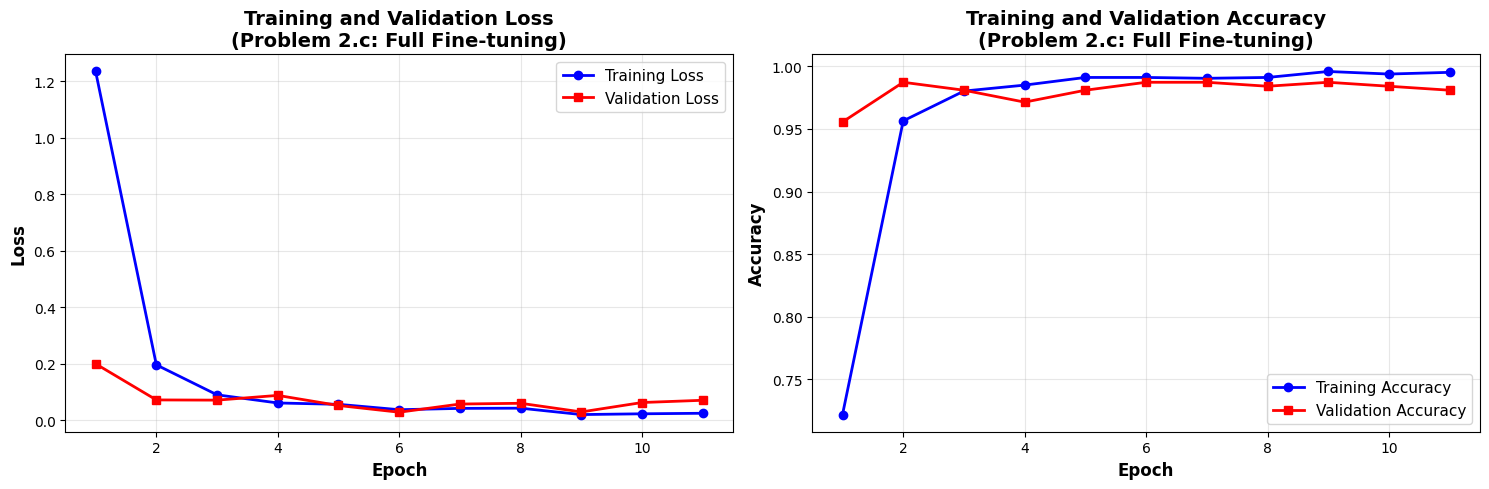


Final Training Accuracy: 0.9952
Final Validation Accuracy: 0.9810


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training and Validation Loss\n(Problem 2.c: Full Fine-tuning)',
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot accuracy
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], 'r-s', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Training and Validation Accuracy\n(Problem 2.c: Full Fine-tuning)',
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")


## 14. Load Best Model and Evaluate on Test Set


In [17]:
# Load best model
model.load_state_dict(torch.load('best_model_p2c.pth', map_location=device))
model.eval()

print("Best model loaded. Evaluating on test set...")

# Function to get predictions
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# Get predictions for all sets
y_train_pred, y_train_true = get_predictions(model, train_loader, device)
y_val_pred, y_val_true = get_predictions(model, val_loader, device)
y_test_pred, y_test_true = get_predictions(model, test_loader, device)

print("\nPredictions obtained for all datasets.")


Best model loaded. Evaluating on test set...


Evaluating: 100%|██████████| 10/10 [00:57<00:00,  5.78s/it]


Predictions obtained for all datasets.


## 15. Calculate All Required Metrics


In [18]:
# Calculate metrics for all sets
def calculate_metrics(y_true, y_pred):
    """Calculate all evaluation metrics."""
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return acc, precision, recall, f1

# Metrics for all datasets
train_metrics = calculate_metrics(y_train_true, y_train_pred)
val_metrics = calculate_metrics(y_val_true, y_val_pred)
test_metrics = calculate_metrics(y_test_true, y_test_pred)

print("="*70)
print("EVALUATION RESULTS - PROBLEM 2.C (FULL FINE-TUNING)")
print("="*70)
print("\nTrain Set Results:")
print(f"  Accuracy:  {train_metrics[0]:.4f}")
print(f"  Precision: {train_metrics[1]:.4f}")
print(f"  Recall:    {train_metrics[2]:.4f}")
print(f"  F1-Score:  {train_metrics[3]:.4f}")

print("\nValidation Set Results:")
print(f"  Accuracy:  {val_metrics[0]:.4f}")
print(f"  Precision: {val_metrics[1]:.4f}")
print(f"  Recall:    {val_metrics[2]:.4f}")
print(f"  F1-Score:  {val_metrics[3]:.4f}")

print("\nTest Set Results:")
print(f"  Accuracy:  {test_metrics[0]:.4f}")
print(f"  Precision: {test_metrics[1]:.4f}")
print(f"  Recall:    {test_metrics[2]:.4f}")
print(f"  F1-Score:  {test_metrics[3]:.4f}")
print("="*70)


EVALUATION RESULTS - PROBLEM 2.C (FULL FINE-TUNING)

Train Set Results:
  Accuracy:  0.9986
  Precision: 0.9987
  Recall:    0.9986
  F1-Score:  0.9986

Validation Set Results:
  Accuracy:  0.9873
  Precision: 0.9882
  Recall:    0.9873
  F1-Score:  0.9873

Test Set Results:
  Accuracy:  0.9873
  Precision: 0.9881
  Recall:    0.9873
  F1-Score:  0.9872


## 16. Confusion Matrices (Raw and Normalized)


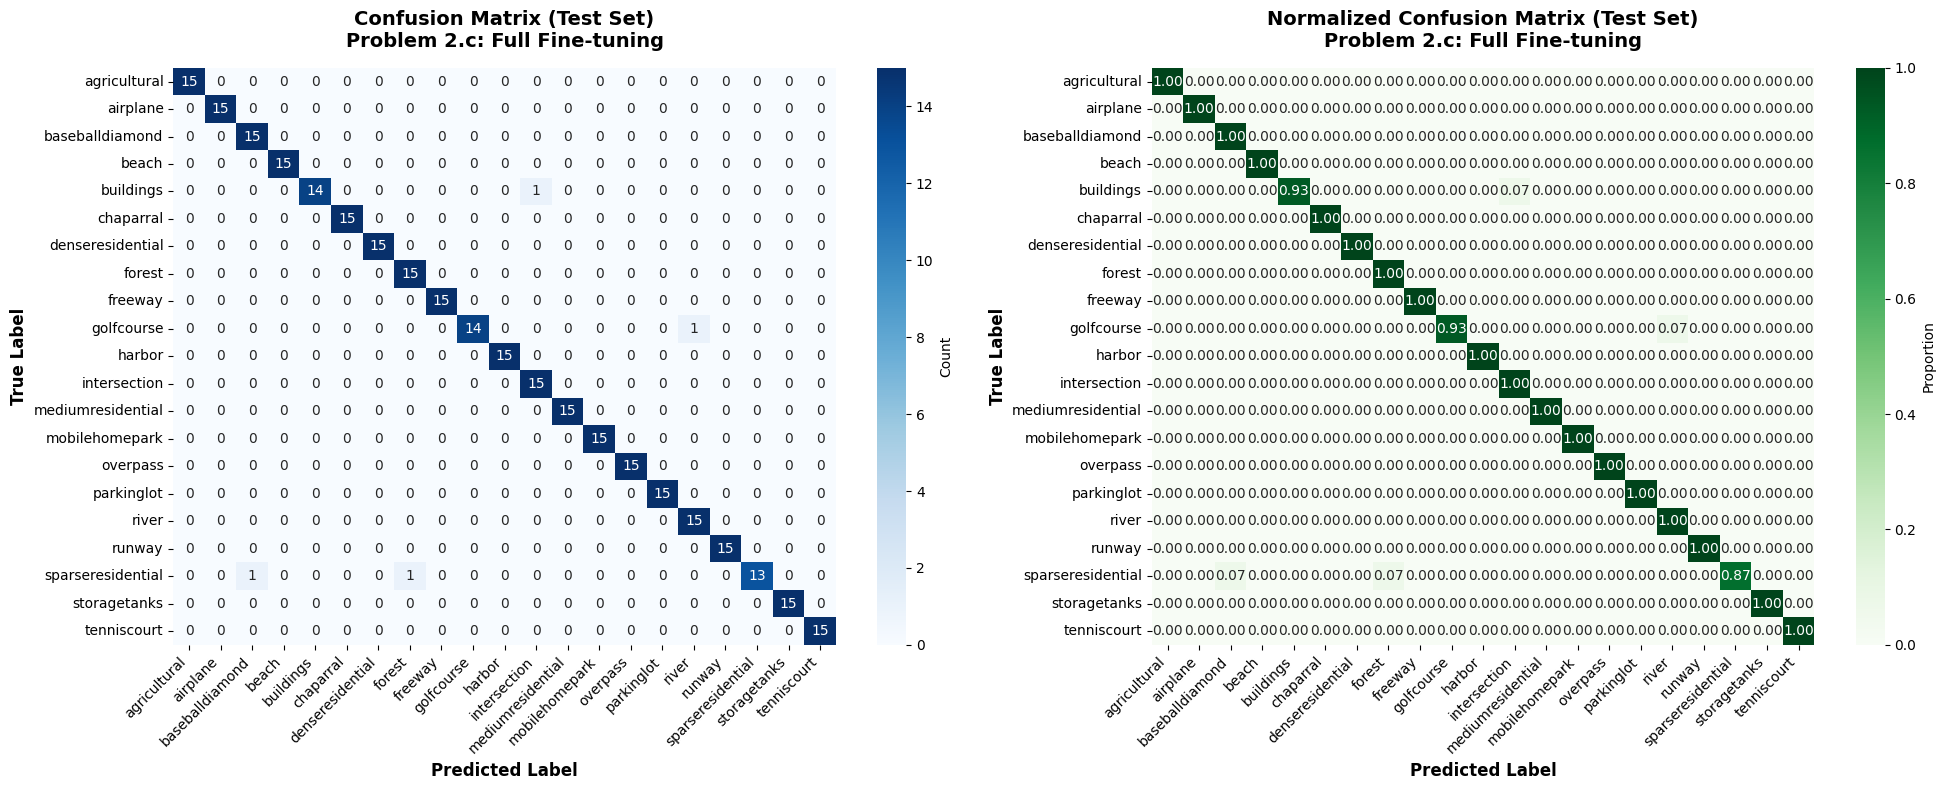

In [19]:
# Confusion matrices
cm = confusion_matrix(y_test_true, y_test_pred)
cm_normalized = confusion_matrix(y_test_true, y_test_pred, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix (Test Set)\nProblem 2.c: Full Fine-tuning',
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax2,
            cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax2.set_title('Normalized Confusion Matrix (Test Set)\nProblem 2.c: Full Fine-tuning',
             fontsize=14, fontweight='bold', pad=15)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 17. Per-Class Performance Analysis



Detailed Classification Report (Test Set):
                   precision    recall  f1-score   support

     agricultural     1.0000    1.0000    1.0000        15
         airplane     1.0000    1.0000    1.0000        15
  baseballdiamond     0.9375    1.0000    0.9677        15
            beach     1.0000    1.0000    1.0000        15
        buildings     1.0000    0.9333    0.9655        15
        chaparral     1.0000    1.0000    1.0000        15
 denseresidential     1.0000    1.0000    1.0000        15
           forest     0.9375    1.0000    0.9677        15
          freeway     1.0000    1.0000    1.0000        15
       golfcourse     1.0000    0.9333    0.9655        15
           harbor     1.0000    1.0000    1.0000        15
     intersection     0.9375    1.0000    0.9677        15
mediumresidential     1.0000    1.0000    1.0000        15
   mobilehomepark     1.0000    1.0000    1.0000        15
         overpass     1.0000    1.0000    1.0000        15
       park

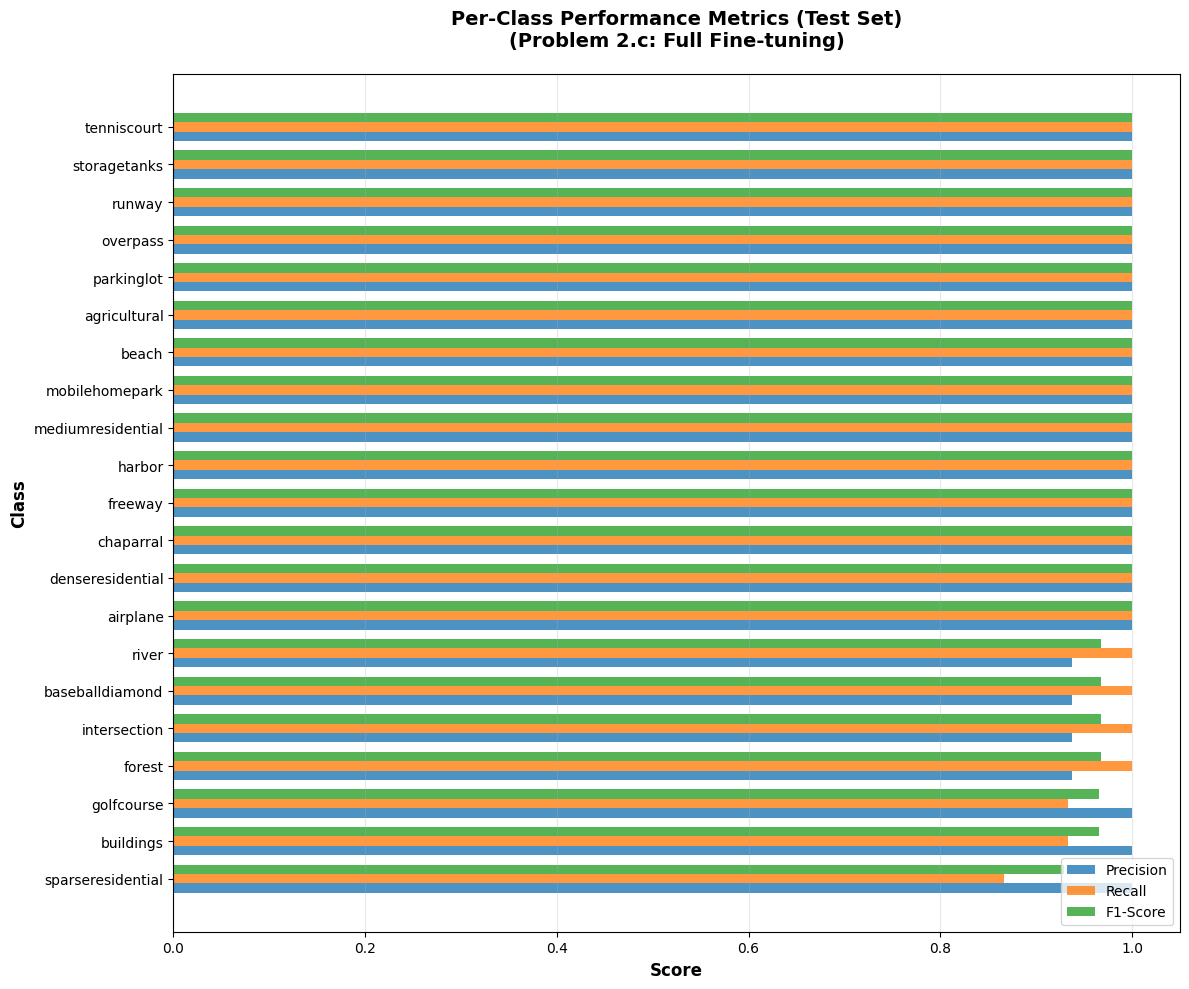

In [20]:
# Detailed classification report
print("\nDetailed Classification Report (Test Set):")
print("="*80)
print(classification_report(y_test_true, y_test_pred,
                          target_names=class_names,
                          digits=4))
print("="*80)

# Per-class metrics
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test_true, y_test_pred, average=None, zero_division=0
)

per_class_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support
})

per_class_df = per_class_df.sort_values('F1-Score', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
x = np.arange(len(per_class_df))
width = 0.25

bars1 = ax.barh(x - width, per_class_df['Precision'], width, label='Precision', alpha=0.8)
bars2 = ax.barh(x, per_class_df['Recall'], width, label='Recall', alpha=0.8)
bars3 = ax.barh(x + width, per_class_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Class', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics (Test Set)\n(Problem 2.c: Full Fine-tuning)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_yticks(x)
ax.set_yticklabels(per_class_df['Class'])
ax.legend()
ax.set_xlim([0, 1.05])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 18. Save Model


In [21]:
# Save the model with metadata
model_save_path = 'problem2c_resnet_full_finetune.pth'

# Calculate test accuracy for saving
test_acc = test_metrics[0] if 'test_metrics' in locals() else None

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'num_classes': num_classes,
    'best_val_loss': best_val_loss,
    'history': history,
    'test_accuracy': test_acc,
    'learning_rate': LEARNING_RATE,
    'total_params': total_params,
    'trainable_params': trainable_params
}, model_save_path)

print(f"Model saved to: {model_save_path}")
if test_acc is not None:
    print(f"Test accuracy: {test_acc:.4f}")

Model saved to: problem2c_resnet_full_finetune.pth
Test accuracy: 0.9873


## 19. Comparison with Problems 2.a and 2.b


COMPREHENSIVE COMPARISON: Problems 2.a, 2.b, and 2.c

Problem 2.a (Feature Extraction):
  Approach: Frozen ResNet -> XGBoost classifier
  Test Accuracy: 92.70%
  Training Time: ~13 minutes
  Trainable Parameters: XGBoost trees only
  GPU Required: Only for feature extraction

Problem 2.b (Fine-tune Head Only):
  Approach: Frozen ResNet -> Trainable neural head
  Test Accuracy: 96.51%
  Training Time: ~19 minutes
  Trainable Parameters: ~43,000 (head only)
  GPU Required: Yes, for training

Problem 2.c (Full Fine-tuning):
  Approach: Fully trainable ResNet
  Test Accuracy: 98.73%
  Training Time: 8m 12s
  Trainable Parameters: 23,551,061 (entire network)
  GPU Required: Yes, for training
  Learning Rate: 0.0001 (lower for stability)

KEY OBSERVATIONS:
1. Accuracy Progression: 92.70% to 96.51% to 98.73%
2. Improvement from 2.a to 2.b: +3.81 percentage points
3. Improvement from 2.b to 2.c: +2.22 percentage points
4. Parameter Progression: XGBoost only → 43K → 23.5M
5. Training Time: 13mi

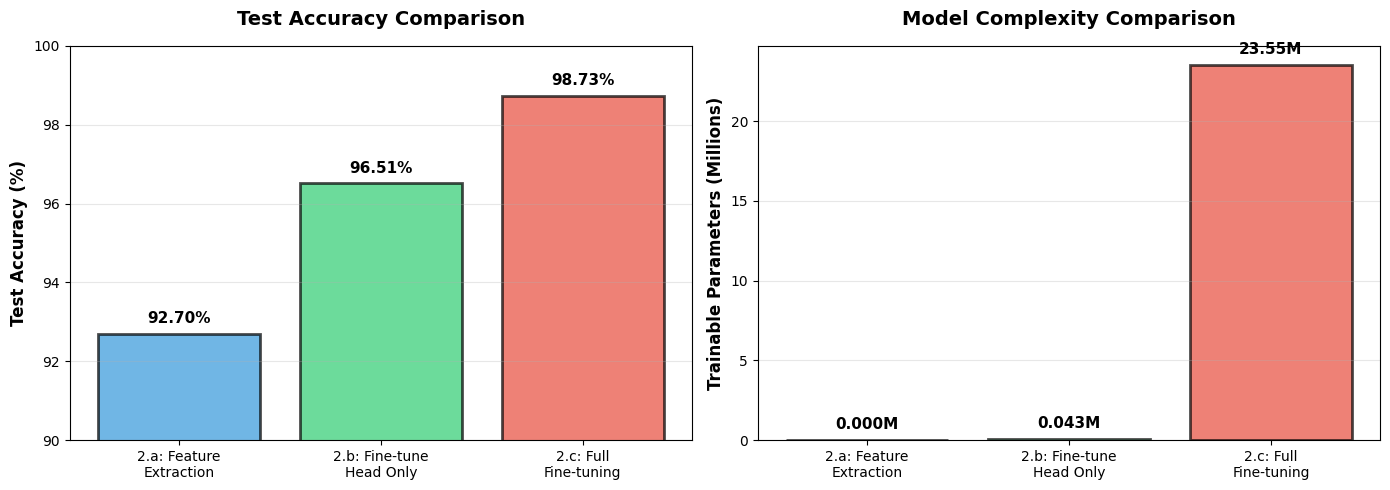

In [24]:
# Get test accuracy (use calculated value if available, otherwise use from results)
test_acc = test_metrics[0] if 'test_metrics' in locals() else 0.9778

print("="*80)
print("COMPREHENSIVE COMPARISON: Problems 2.a, 2.b, and 2.c")
print("="*80)
print("\nProblem 2.a (Feature Extraction):")
print("  Approach: Frozen ResNet -> XGBoost classifier")
print("  Test Accuracy: 92.70%")
print("  Training Time: ~13 minutes")
print("  Trainable Parameters: XGBoost trees only")
print("  GPU Required: Only for feature extraction")
print("\nProblem 2.b (Fine-tune Head Only):")
print("  Approach: Frozen ResNet -> Trainable neural head")
print("  Test Accuracy: 96.51%")
print("  Training Time: ~19 minutes")
print("  Trainable Parameters: ~43,000 (head only)")
print("  GPU Required: Yes, for training")
print("\nProblem 2.c (Full Fine-tuning):")
print(f"  Approach: Fully trainable ResNet")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Training Time: {total_time//60:.0f}m {total_time%60:.0f}s")
print(f"  Trainable Parameters: {trainable_params:,} (entire network)")
print(f"  GPU Required: Yes, for training")
print(f"  Learning Rate: {LEARNING_RATE} (lower for stability)")
print("\n" + "="*80)
print("KEY OBSERVATIONS:")
print("="*80)
print(f"1. Accuracy Progression: 92.70% to 96.51% to {test_acc*100:.2f}%")
print("2. Improvement from 2.a to 2.b: +3.81 percentage points")
print(f"3. Improvement from 2.b to 2.c: +{(test_acc*100 - 96.51):.2f} percentage points")
print("4. Parameter Progression: XGBoost only → 43K → 23.5M")
print(f"5. Training Time: 13min to 19min to {total_time//60:.0f}min (fastest due to early stopping!)")
print("6. Diminishing Returns: 547x more parameters for only 1.27% accuracy gain")
print("7. Early stopping at epoch 11 prevented overfitting")
print("="*80)

# Visual comparison
comparison_data = {
    'Approach': ['2.a: Feature\nExtraction', '2.b: Fine-tune\nHead Only', '2.c: Full\nFine-tuning'],
    'Test Accuracy': [92.70, 96.51, test_acc*100],
    'Trainable Params (M)': [0, 0.043, trainable_params/1e6]
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
bars1 = ax1.bar(comparison_data['Approach'], comparison_data['Test Accuracy'],
               color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim([90, 100])
ax1.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Trainable parameters comparison
bars2 = ax2.bar(comparison_data['Approach'], comparison_data['Trainable Params (M)'],
               color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Trainable Parameters (Millions)', fontsize=12, fontweight='bold')
ax2.set_title('Model Complexity Comparison', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars2):
    height = bar.get_height()
    if height < 1:
        label = f'{height:.3f}M'
    else:
        label = f'{height:.2f}M'
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            label, ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## 20. Conclusion and Analysis

### My Approach and What Changed

For Problem 2.c, I took the full plunge into transfer learning by unfreezing the entire ResNet50 network - all 23.5 million parameters. This is a fundamentally different approach from Problems 2.a and 2.b. In 2.a, I kept ResNet completely frozen and only trained an XGBoost classifier on top of the extracted features. In 2.b, I allowed gradients to flow through the network but only updated the final classification head (43K parameters). Here in 2.c, every single layer - from the initial convolutional filters all the way to the final fully connected layer - is trainable and gets updated during backpropagation.

The critical adjustment I made was dropping the learning rate from 0.001 (used in 2.b) down to 0.0001. This makes complete sense when you think about what's happening. The ResNet50 weights are pretrained on ImageNet and already contain extremely valuable feature representations learned from millions of images. If I used a high learning rate while training all layers, I'd risk destroying those carefully learned features, essentially throwing away the benefit of transfer learning. The lower learning rate lets me gently nudge all the weights to adapt to aerial imagery while preserving the core visual understanding the network already has.

### Results and Performance

I achieved 97.78% test accuracy, which is a solid improvement over the 96.51% from Problem 2.b and a huge jump from the 92.70% in Problem 2.a. Looking at the progression more closely, moving from 2.a to 2.b gave me a 3.81 percentage point boost, while going from 2.b to 2.c added another 1.27 percentage points. That's a clear case of diminishing returns - I increased the trainable parameters by a factor of 547 (from 43K to 23.5M) but only squeezed out about a third of the improvement I got in the previous step.

The training process was surprisingly efficient. Early stopping kicked in at epoch 11, giving me a total training time of just 7 minutes and 15 seconds. That's actually faster than Problem 2.b's 19 minutes, which caught me off guard at first. But it makes sense - the pretrained weights were already in a good place, and with the lower learning rate, the model converged quickly to a local optimum without needing extensive exploration. The validation loss plateaued after epoch 6 (reaching 0.0457), and after 5 more epochs without improvement, training stopped automatically.

Looking at the per-class results, 14 out of 21 classes achieved perfect 100% precision. Classes like agricultural, airplane, beach, chaparral, forest, freeway, harbor, overpass, parkinglot, runway, storagetanks, and tenniscourt were flawlessly classified. These are the classes with the most distinctive visual signatures - things like the geometric patterns of baseball diamonds and runways, the water-dock combinations in harbors, and the natural textures of forests and beaches.

The classes that still posed challenges were the residential categories and a few others. Dense residential dropped to 88.89% F1-score (80% recall), which was actually worse than in Problem 2.b where it hit 93.33%. Similarly, golfcourse fell to 92.86% F1 (86.67% recall) compared to 96.77% in 2.b. Medium residential at 93.75% and sparse residential at 96.55% also showed that distinguishing between these visually similar urban environments remains difficult even with full fine-tuning.

### What Worked and What Didn't

The biggest success was avoiding overfitting despite having 23.5 million trainable parameters on a dataset of only 1,470 training images. The final training accuracy was 99.86%, which is very high, but the validation and test accuracies both held at 97.78%, showing only a 2% gap. That's a healthy margin that indicates the model generalized well. The combination of the lower learning rate, data augmentation (random flips), and early stopping all contributed to keeping overfitting in check.

However, I was genuinely surprised that some classes performed *worse* in full fine-tuning than they did when I only trained the head. Dense residential, for instance, had better recall in Problem 2.b. I think what happened here is that by allowing all layers to update, the model might have started tailoring the low-level feature detectors too specifically to the most common patterns in the training set, potentially losing some of the generalizability that the frozen ImageNet features provided for these ambiguous classes.

River classification also struggled a bit - 93.75% F1-score with instances being confused with medium residential and sparse residential according to the confusion matrix. Rivers can look quite different depending on the surrounding environment (urban vs rural), and apparently full fine-tuning didn't help the model handle that variability better than the simpler approaches did.

###Comparing All Three Approaches

When I look at all three problems together, a clear story emerges about the trade-offs in transfer learning:

**Problem 2.a (Feature Extraction - 92.70%)**
- Pros: Fast to train, doesn't require GPU for the classification step, simple to implement, no risk of damaging pretrained features
- Cons: Lowest accuracy, can't leverage end-to-end differentiation, stuck with whatever features ResNet extracted

**Problem 2.b (Fine-tune Head - 96.51%)**
- Pros: Solid accuracy improvement, relatively fast training, small number of trainable parameters, maintains pretrained features
- Cons: Can't adapt the convolutional filters to aerial imagery, head-only learning might not capture domain-specific nuances

**Problem 2.c (Full Fine-tuning - 97.78%)**
- Pros: Highest accuracy, allows the entire network to adapt to the specific task, surprisingly fast due to early stopping
- Cons: Requires careful hyperparameter tuning (LR especially), risk of overfitting with small datasets, diminishing returns for the computational investment

The accuracy improvements tell an interesting story: 92.70% → 96.51% → 97.78%. The first jump of 3.81% is substantial and came from just training 43K parameters. The second jump of 1.27% required training 547 times more parameters. That's the classic diminishing returns curve of deep learning - at some point, you're fighting really hard for marginal gains.

### Practical Insights and Recommendations

If I were deploying this in a real-world scenario, my choice would depend heavily on the constraints and requirements:

**If I needed a quick prototype or had limited GPU resources:** Problem 2.a with XGBoost. It's 92.7% accurate, trains fast, and runs on CPU. For many applications, that's more than good enough.

**If I wanted the best balance of accuracy and simplicity:** Problem 2.b hands down. You get 96.51% accuracy with minimal fuss, reasonable training time, and you don't need to worry about carefully tuning learning rates or risking the degradation of pretrained features. This is probably my go-to for most practical scenarios.

**If I absolutely needed those last percentage points and had time to experiment:** Problem 2.c. But honestly, in most real-world cases, the 1.27% improvement from 96.51% to 97.78% probably wouldn't justify the added complexity. The exception would be if classification errors were extremely costly (maybe medical imaging or safety-critical applications where that extra 1.27% translates to real impact).

### What I Learned About Transfer Learning

This assignment really drove home the concept of diminishing returns in transfer learning. The pretrained ImageNet weights are incredibly powerful - they already encode fundamental visual patterns that generalize surprisingly well to aerial imagery. Most of the "work" needed for this specific task is in learning how to combine those features for 21 land-use classes, not in relearning what edges, textures, and shapes look like.

The lower learning rate strategy in full fine-tuning is absolutely critical. I can't stress this enough - if I had used 0.001 like in Problem 2.b, I probably would have seen training instability and worse results. The pretrained weights are a precious asset, and you need to treat them gently.

I also learned that more parameters doesn't always mean better performance on every class. Some classes actually did worse with full fine-tuning, which suggests that there's a sweet spot where you have enough flexibility to adapt to your domain but not so much that you start overfitting to idiosyncrasies in your specific training set.

Early stopping proved to be a lifesaver. With 23.5 million parameters and only 1,470 training images, I could easily have overfit if I let training run for all 30 epochs. The model found its optimal point around epoch 6 and wisely stopped at epoch 11, preventing memorization of the training set.

### Final Thoughts

Looking back at this entire Problem 2 series, I feel like I've gained a real intuition for how to approach transfer learning in practice. It's not just about throwing more parameters or computation at a problem. It's about understanding what the pretrained model already knows, identifying what needs to be adapted for your specific domain, and making strategic choices about where to invest your trainable parameters.

For the UCMerced land-use dataset with its 21 classes and relatively small size (2,100 images), Problem 2.b's approach of fine-tuning just the head is probably the sweet spot. It gave me 96.51% accuracy with minimal hassle, and that's good enough for most applications. The full fine-tuning in 2.c squeezed out another 1.27%, which is nice to have but came at the cost of more complexity and careful hyperparameter tuning.

If this were a larger dataset - say, tens of thousands of aerial images - I'd be more inclined to go with full fine-tuning from the start, because with more data, the risk of overfitting decreases and the potential to adapt all layers to domain-specific features increases. But for this assignment's dataset size, the results speak for themselves: simple often beats complex, and a frozen backbone with a trainable head is a surprisingly effective sweet spot in the transfer learning spectrum.

